# Conservatively diagnosing model transports into an arbitrary closed region with `sectionate`

## Import packages

In [1]:
import numpy as np
import xgcm
import xarray as xr
import matplotlib.pyplot as plt

import sectionate
print(f"Sectionate version: {sectionate.__version__}")

Sectionate version: 0.3.3


## Load example model grid and transport diagnosics

In [2]:
from load_example_model_grid import load_MOM6_example_grid
grid = load_MOM6_example_grid()
ds = grid._ds

## Define the two OSNAP sections:

In [3]:
Labrador_section_lons=[-56.8775, -52.0956, -49.8604, -47.6107, -44.8000, -50, -65, -65]
Labrador_section_lats=[52.0166, 52.6648, 53.5577, 58.8944, 60.4000, 71, 63.5, 57.5]
Labrador_section_lons = np.append(Labrador_section_lons, Labrador_section_lons[0])
Labrador_section_lats = np.append(Labrador_section_lats, Labrador_section_lats[0])

## Closed section surrounding Labrador Sea

In [4]:
i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    Labrador_section_lons,
    Labrador_section_lats,
    topology="MOM-tripolar"
)

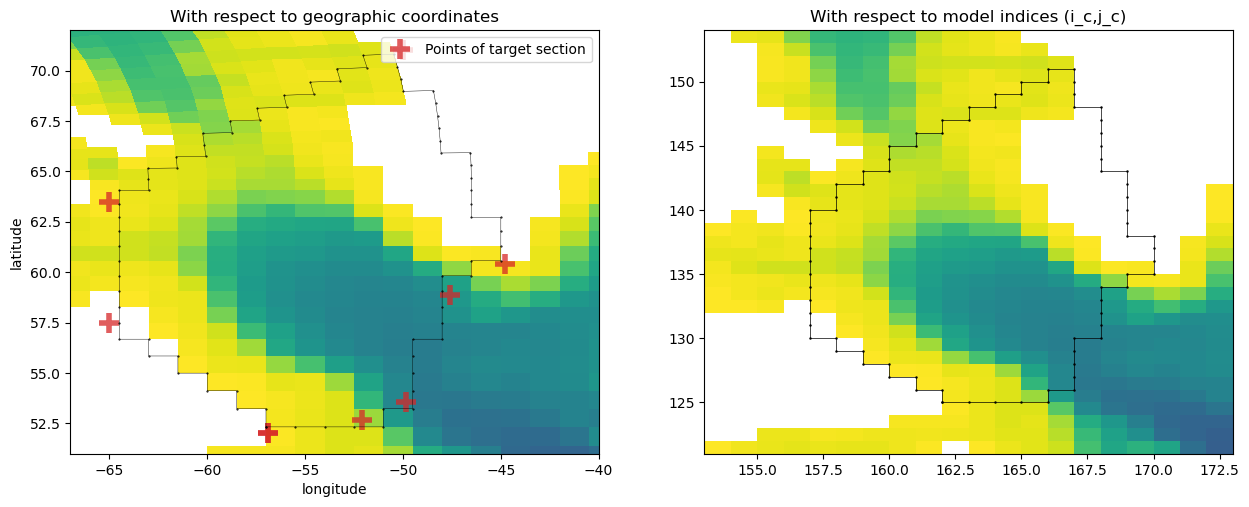

In [5]:
depth_masked = ds['deptho'].where(ds['deptho'] != 0)

plt.figure(figsize=[15,5.5])
plt.subplot(1,2,1)
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], depth_masked, cmap="viridis_r")
plt.plot(Labrador_section_lons, Labrador_section_lats, "C3+", markersize=15., mew=4., alpha=0.75, label="Points of target section")
plt.plot(lons_c, lats_c, 'k.-', markersize=1., lw=0.3)
plt.axis([-67,-40, 51, 72])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("With respect to geographic coordinates")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.pcolormesh(depth_masked, cmap="viridis_r")
plt.plot(i_c, j_c, 'k.-', markersize=1.5, lw=0.5)
plt.axis(np.array([920, 1040, 730, 925])//6)
plt.title("With respect to model indices (i_c,j_c)")
plt.show()

### Plot the hydrography and cell-integrated mass transport across the section

In [6]:
T = sectionate.extract_tracer('thetao', grid, i_c, j_c)

In [7]:
Trp = sectionate.convergent_transport(grid, i_c, j_c, layer="sigma2_l", interface="sigma2_i")
Trp = Trp.assign_coords({"distance": xr.DataArray(Trp.dl.cumsum("sect").values, dims=("sect",), attrs={"units":"m"})})

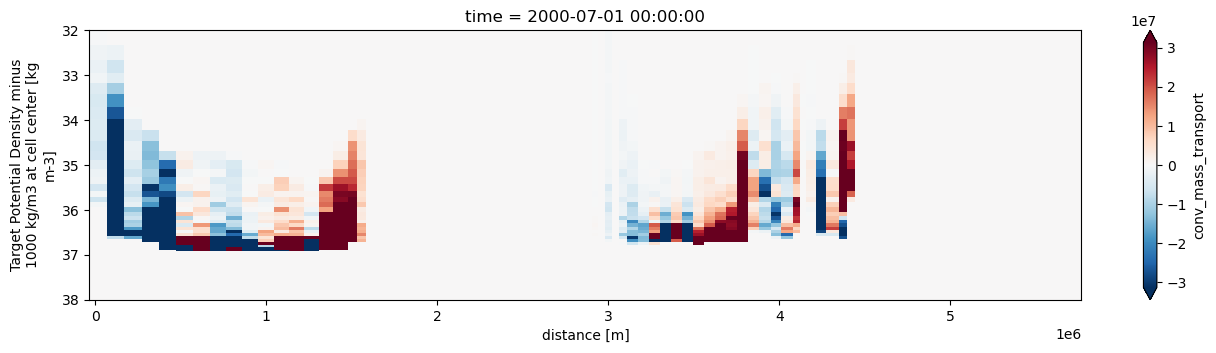

In [8]:
plt.figure(figsize=(16, 3.5))
Trp.isel(time=0)['conv_mass_transport'].swap_dims({'sect':'distance'}).plot(
    cmap='RdBu_r', x="distance", yincrease=False, ylim=[38,32], robust=True
);